# Beyond the Score — Credit Decisioning Case

## tl;dr

Calibrated gradient boosting was selected on validation expected value. On the untouched test set it achieved ROC-AUC **0.764**, Gini **0.527**, KS **0.386**, and Brier **0.171**. Under the explicit 15% target bad-rate scenario, the expected-value policy produced **17,179 illustrative value units per 100 applications**, 226% above approve-all. The result is a benchmark demonstration, not a lending policy.

## Context & Methods

The model estimates bad-credit probability; a separate policy converts probability into a decision. Logistic regression and calibrated gradient boosting share the same 17 application-time inputs. Model selection uses the validation partition only, followed by one held-out test report.

### Key Assumptions

- Source bad-rate prior: 30% by stratified sampling design.
- Illustrative operating prior: 15%.
- Good-account margin: 18% of the transformed amount proxy.
- Loss given default: 65% of the proxy.
- Operating cost: 50 value units.
- No timestamp exists, so the split cannot be out-of-time.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image

from src.data import data_quality_summary, load_credit_data, split_credit_data
from src.train_evaluate import evaluate

ROOT = Path.cwd()
pd.set_option("display.max_columns", 30)

## Data

The source is the corrected UCI South German Credit release. The checks below lock its grain, completeness, target distribution, and modeling contract.

In [2]:
credit = load_credit_data()
splits = split_credit_data(credit)
display(data_quality_summary(credit))
pd.DataFrame({
    "partition": ["train", "validation", "test"],
    "rows": [len(splits.train), len(splits.validation), len(splits.test)],
    "bad_credits": [splits.train.bad_credit.sum(), splits.validation.bad_credit.sum(), splits.test.bad_credit.sum()],
})

,check,observed,expected,passed
0,rows,1000,1000,True
1,columns_after_derivation,22,22,True
2,missing_cells,0,0,True
3,duplicate_rows,0,0,True
4,bad_credit_rows,300,300,True
5,model_features,17,17,True
6,audit_only_features,3,3,True


,partition,rows,bad_credits
0,train,600,180
1,validation,200,60
2,test,200,60


## Results

The evaluation regenerates every report and figure. Bootstrap intervals use 1,000 deterministic resamples.

In [3]:
summary = evaluate(n_bootstrap=1000)
summary

{'champion': 'Calibrated Gradient Boosting', 'validation_selection_metric': 'value_units_per_100_applications', 'test_expected_value_policy': {'approval_rate': 0.6475, 'expected_bad_rate': 0.08108108108108104, 'value_units_per_100_applications': 17179.242142857136, 'value_95_ci': [8127.307760285386, 25506.96503558718]}, 'scenario': {'source_bad_rate': 0.3, 'target_bad_rate': 0.15, 'good_margin_rate': 0.18, 'loss_given_default': 0.65, 'operating_cost_units': 50.0, 'amount_warning': 'Amount is an historical transformed proxy; values are illustrative, not currency forecasts.'}}

In [4]:
metrics = pd.read_csv(ROOT / "reports/model_metrics.csv")
metrics[metrics.split == "test"].round(3)

,model,split,roc_auc,roc_auc_ci_low,roc_auc_ci_high,gini,average_precision,brier_score,log_loss,ks,mean_probability_bad
1,Logistic Regression,test,0.734,0.654,0.810,0.468,0.574,0.181,0.549,0.355,0.313
3,Calibrated Gradient Boosting,test,0.764,0.689,0.834,0.527,0.613,0.171,0.516,0.386,0.315


In [5]:
policies = pd.read_csv(ROOT / "reports/policy_comparison.csv")
policies[(policies.model == summary["champion"]) & (policies.split == "test")].round(3)

,model,split,policy,approval_rate,expected_bad_rate,value_units_per_100_applications,approved_rows
9,Calibrated Gradient Boosting,test,Approve all,1.000,0.150,5263.708,200
10,Calibrated Gradient Boosting,test,Fixed PD cutoff,0.562,0.071,15025.619,102
11,Calibrated Gradient Boosting,test,Expected-value policy,0.648,0.081,17179.242,119


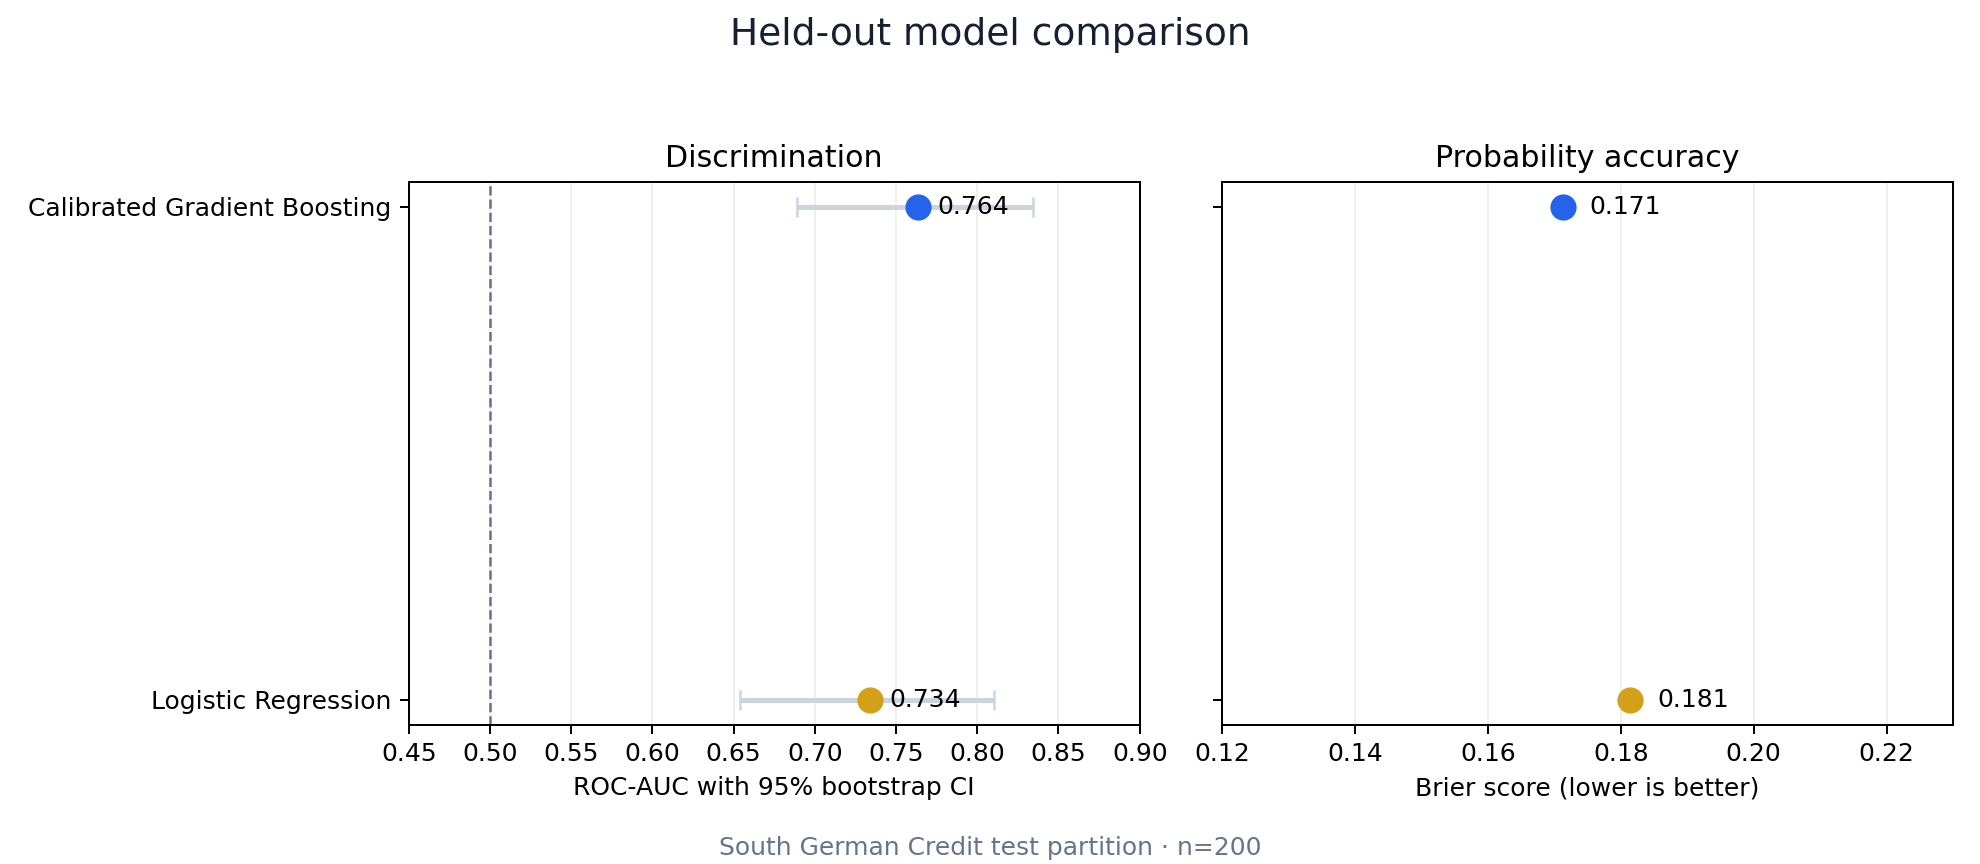

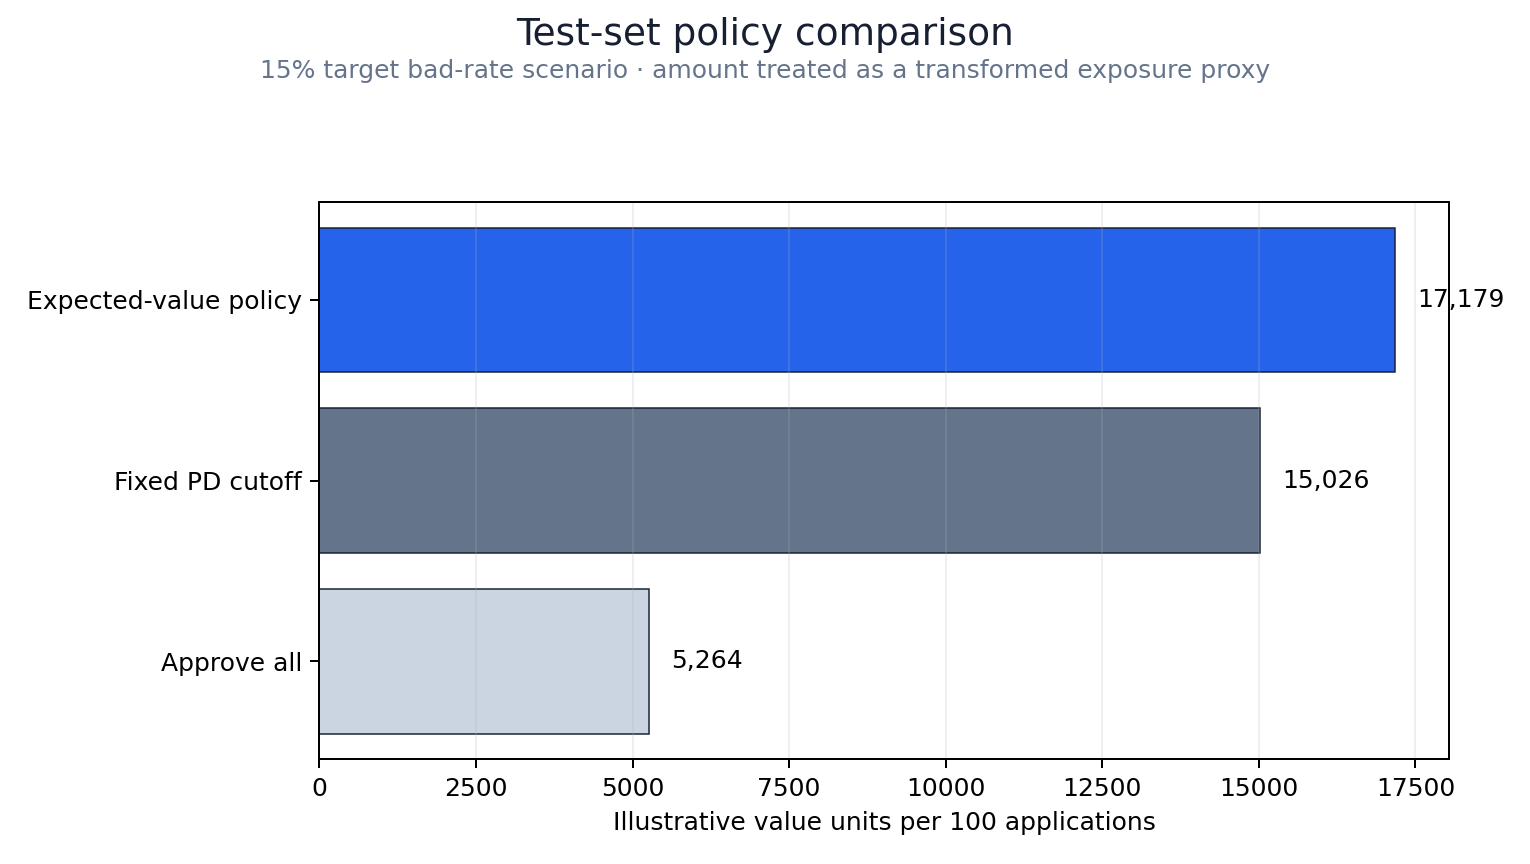

In [6]:
display(Image(filename=ROOT / "reports/figures/model_comparison.png"))
display(Image(filename=ROOT / "reports/figures/policy_value_comparison.png"))

### Governance diagnostics

Protected/problematic attributes are excluded from model inputs. Group metrics are diagnostics with explicit sample-size warnings, and the monitoring batch is synthetic by design.

In [7]:
fairness = pd.read_csv(ROOT / "reports/fairness_audit.csv")
display(fairness.round(3))
display(pd.read_csv(ROOT / "reports/monitoring_demo.csv").head(10).round(3))

,audit_dimension,group,n,good_n,bad_n,selection_rate,selection_rate_ci_low,selection_rate_ci_high,good_applicant_approval_rate,bad_applicant_approval_rate,observed_bad_rate,mean_adjusted_probability_bad,small_sample_warning
0,age_group,25_plus,165,122,43,0.618,0.542,0.689,0.713,0.349,0.261,0.170,False
1,age_group,under_25,35,18,17,0.486,0.330,0.644,0.611,0.353,0.486,0.198,True
2,worker_group,foreign_worker,6,5,1,0.833,0.436,0.970,1.000,0.000,0.167,0.134,True
3,worker_group,not_foreign_worker,194,135,59,0.588,0.517,0.655,0.689,0.356,0.304,0.177,False


,feature,psi,severity
0,duration,2.480,action
1,score_probability_bad,0.337,action
2,amount,0.312,action
3,status,0.143,watch
4,purpose,0.084,stable
5,present_residence,0.035,stable
6,employment_duration,0.033,stable
7,property,0.032,stable
8,telephone,0.032,stable
9,credit_history,0.020,stable


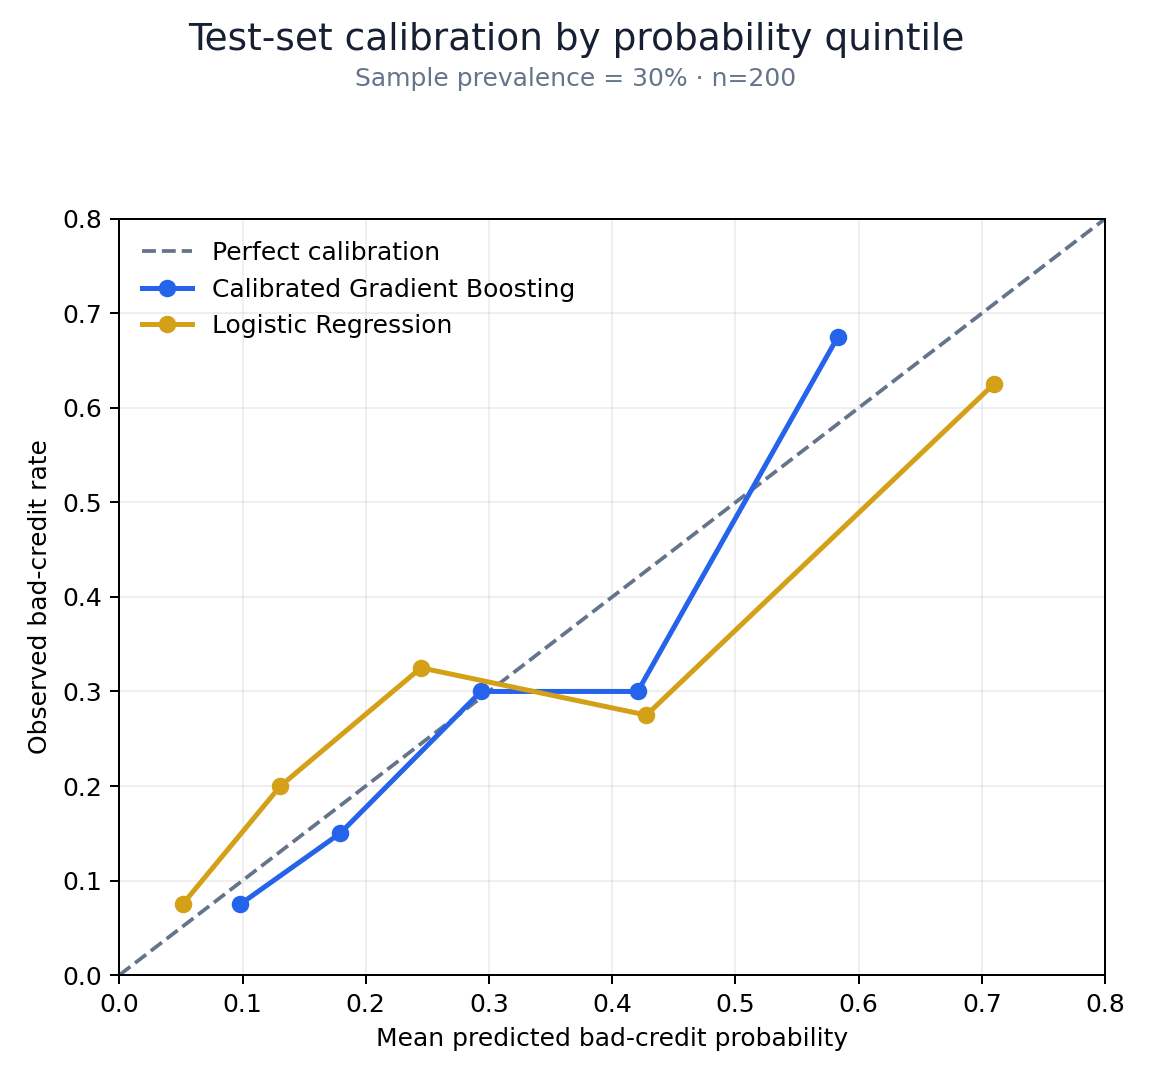

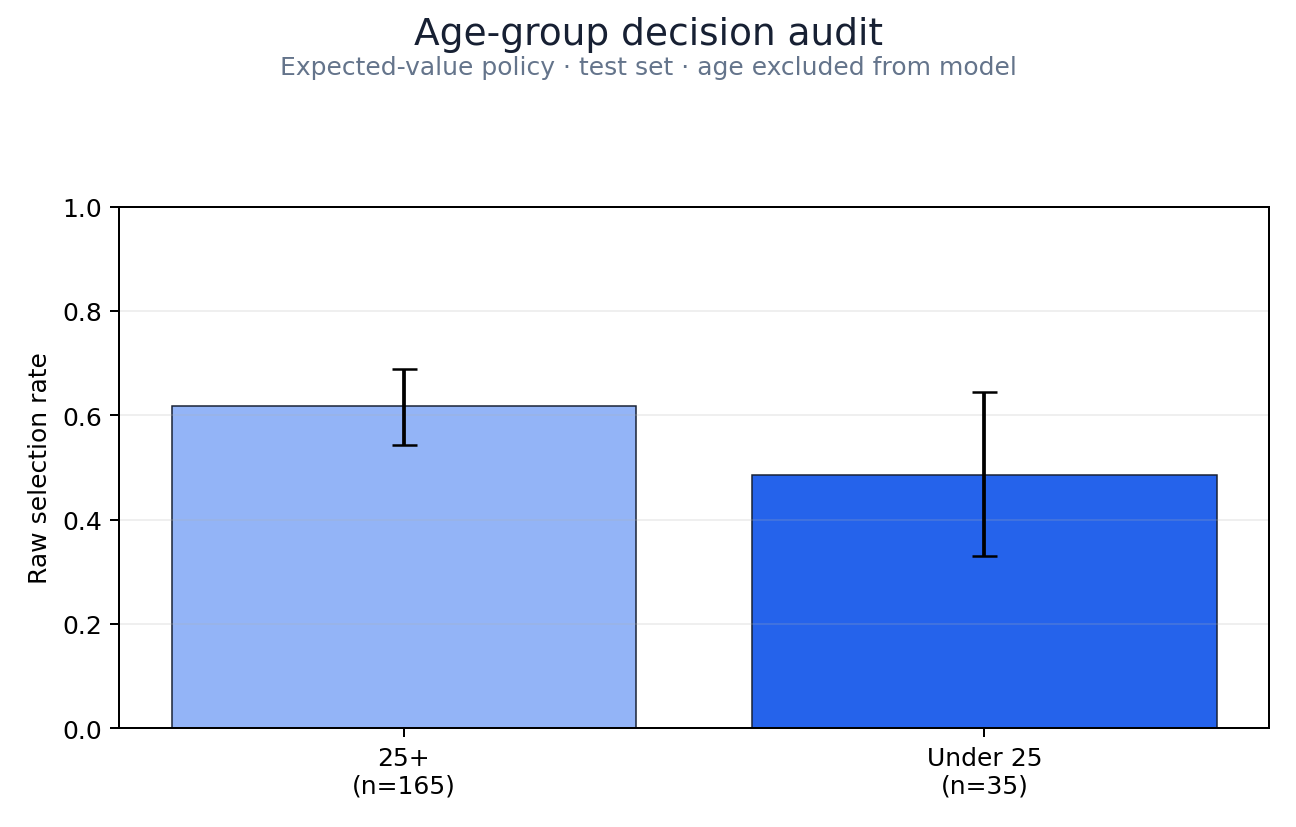

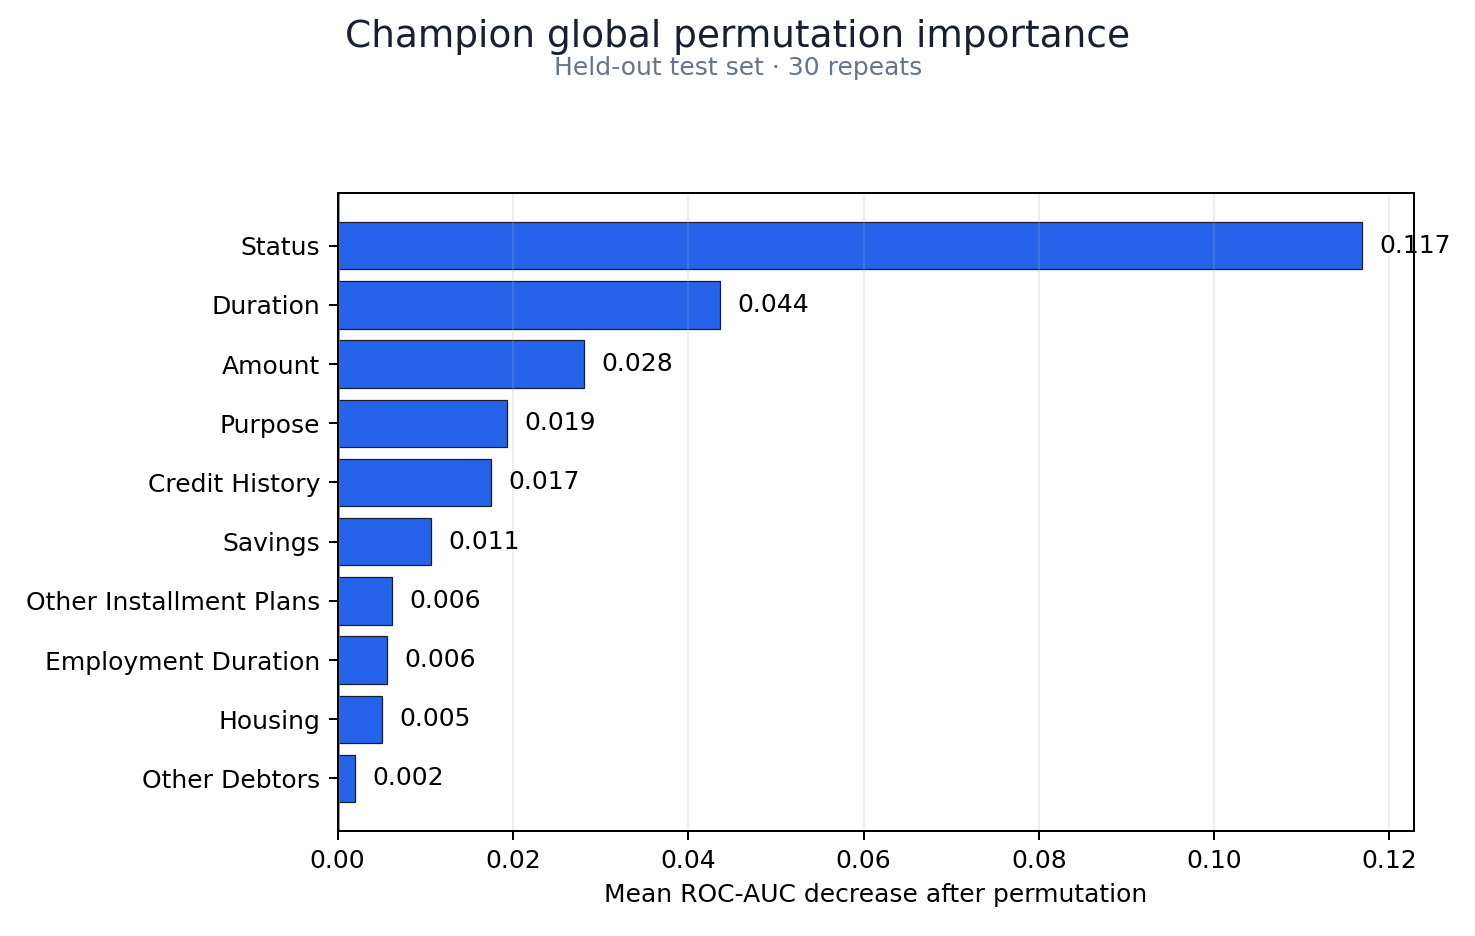

In [8]:
display(Image(filename=ROOT / "reports/figures/calibration.png"))
display(Image(filename=ROOT / "reports/figures/fairness_age_audit.png"))
display(Image(filename=ROOT / "reports/figures/feature_importance.png"))

## Takeaways

1. The nonlinear challenger improved held-out discrimination and Brier score, but uncertainty remains material at n=200.
2. A calibrated risk estimate is not an approval rule. Explicit economics materially changed approval and portfolio-value outcomes.
3. Prior correction is mandatory before applying sample-calibrated probabilities to a different operating prevalence.
4. The observed age-group gap requires investigation but cannot establish discrimination with this small, historical, accepted-only sample.
5. Real deployment requires contemporary application and performance data, reject inference strategy, temporal validation, legal review, governed reason codes, and delayed-outcome monitoring.